In [3]:
!pip install -q -r requirements-colab.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [15]:
!python scripts/testing/evaluate_tablellm_cv.py \
  --input data/llama_tabular_outputs.csv \
  --prompt-column input_text \
  --prediction-column fine_tuned_output \
  --folds 5 \
  --format-only \
  --output-dir outputs/tablellm_format_eval

   fold  rouge_l_f1  text_similarity  format_score  cautious_language  safety_score
      1         NaN              NaN         0.500                0.0           0.5
      2         NaN              NaN         0.750                0.0           1.0
      3         NaN              NaN         0.875                0.5           1.0
      4         NaN              NaN         0.875                0.5           1.0
      5         NaN              NaN         0.625                0.0           0.5
overall         NaN              NaN         0.725                0.2           0.8

Wrote detailed results to: outputs/tablellm_format_eval/tablellm_cv_results.csv
Wrote summary to: outputs/tablellm_format_eval/tablellm_cv_summary.csv
Wrote chart to: outputs/tablellm_format_eval/tablellm_cv_fold_scores.png
Wrote chart to: outputs/tablellm_format_eval/tablellm_cv_operation_scores.png


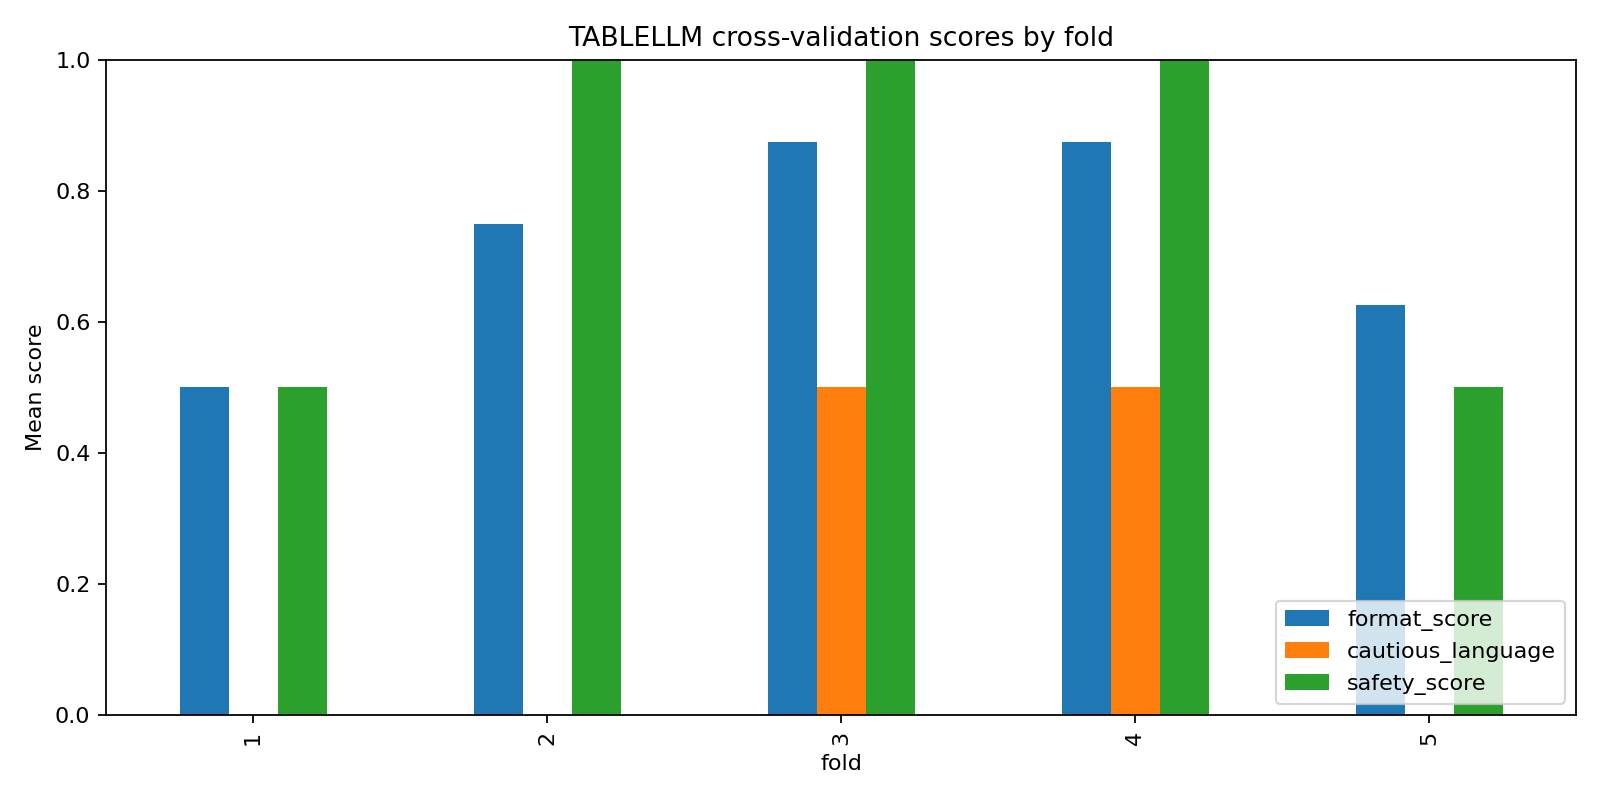

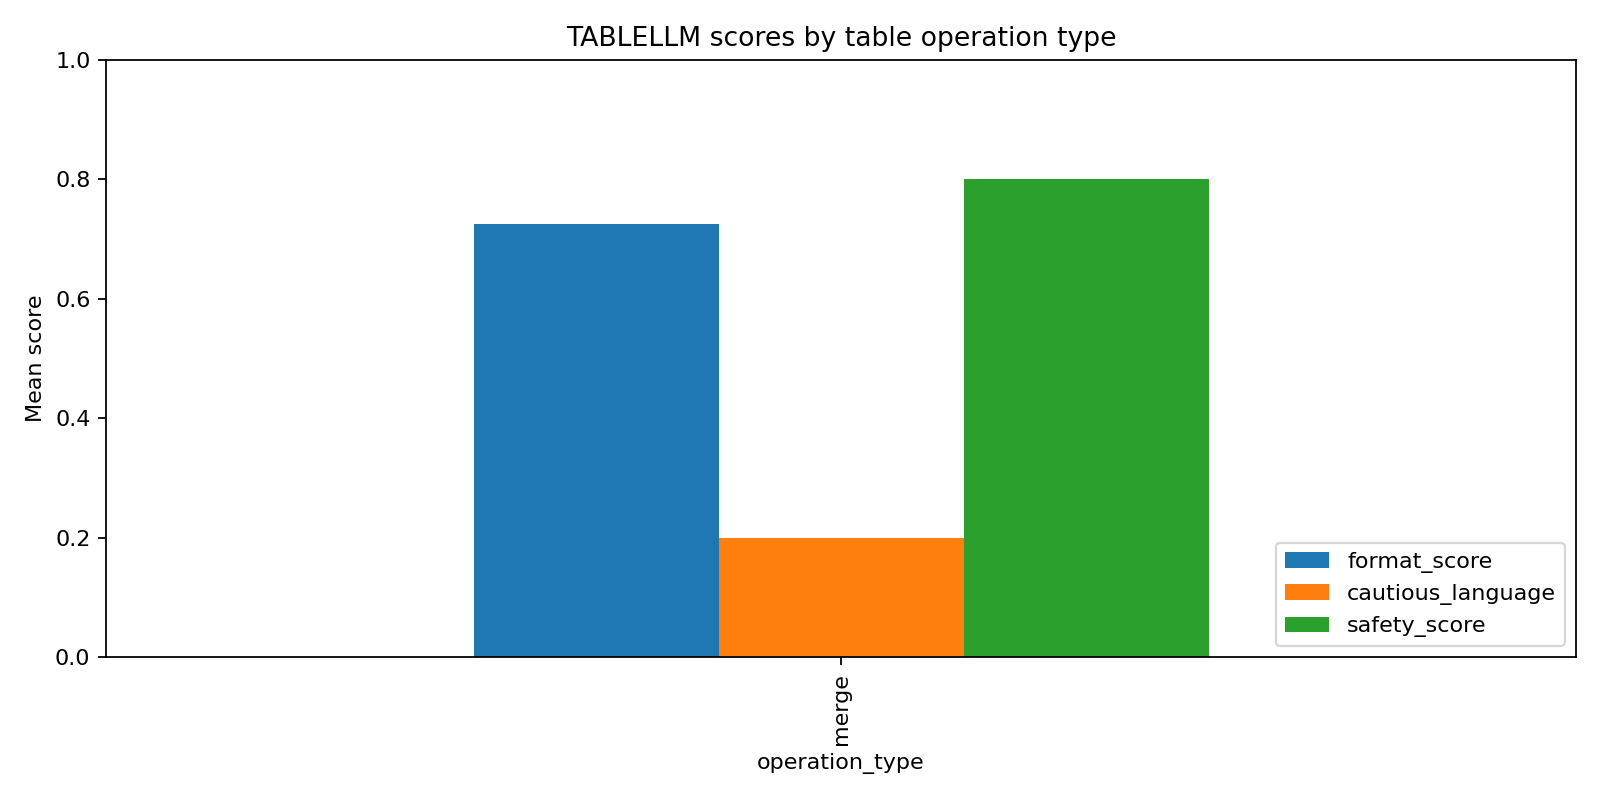

In [18]:
from IPython.display import Image, display

display(Image("/content/NLP_medical_results_explanation/NLP_medical_results_explanation/outputs/tablellm_format_eval/tablellm_cv_fold_scores.png"))
display(Image("/content/NLP_medical_results_explanation/NLP_medical_results_explanation/outputs/tablellm_format_eval/tablellm_cv_operation_scores.png"))

In [19]:
%cd /content/NLP_medical_results_explanation
!git pull

/content/NLP_medical_results_explanation
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 12 (delta 9), reused 12 (delta 9), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 4.00 KiB | 292.00 KiB/s, done.
From https://github.com/veronika-ilioska/NLP_medical_results_explanation
   155c3c3..cc1a0bc  tablellm   -> origin/tablellm
Updating 155c3c3..cc1a0bc
Fast-forward
 README.md                                        |  31 +++
 scripts/silver_standard/fill_row_target_text.py  | 128 ++++++++++++
 scripts/testing/evaluate_tablellm_cv.py          | 118 ++++++++---
 scripts/testing/evaluate_tablellm_cv_colab.ipynb | 243 -----------------------
 4 files changed, 246 insertions(+), 274 deletions(-)
 create mode 100644 scripts/silver_standard/fill_row_target_text.py
 delete mode 100644 scripts/testing/evaluate_tablellm_cv_colab.ipynb


In [20]:
!python scripts/silver_standard/fill_row_target_text.py \
  --input data/llama_tabular_outputs.csv \
  --output data/llama_tabular_outputs_with_targets.csv

Rows: 10
Filled target_text rows: 10
Wrote: data/llama_tabular_outputs_with_targets.csv
   lab_name  VALUE VALUEUOM     FLAG                                                                                       target_text
         pH   7.32    units abnormal                          - pH: 7.32 units - May reflect a change in the body's acid-base balance.
        pO2 236.00    mm Hg abnormal                          - pO2: 236.0 mm Hg - May reflect a change in oxygen levels in the blood.
    Amylase  64.00     IU/L      NaN    - Amylase: 64.0 IU/L - Appears generally within the expected range for body chemistry balance.
  Anion Gap  10.00    mEq/L      NaN - Anion Gap: 10.0 mEq/L - Appears generally within the expected range for body chemistry balance.
Bicarbonate  18.00    mEq/L abnormal                 - Bicarbonate: 18.0 mEq/L - May reflect a change in the body's acid-base balance.


In [21]:
!python scripts/testing/evaluate_tablellm_cv.py \
  --input data/llama_tabular_outputs_with_targets.csv \
  --prompt-column input_text \
  --target-column target_text \
  --prediction-column fine_tuned_output \
  --folds 5 \
  --output-dir outputs/tablellm_cv_real

   fold  rouge_l_f1  text_similarity  format_score  cautious_language  safety_score
      1    0.110654         0.172322         0.500                0.0           0.5
      2    0.180743         0.276144         0.750                0.0           1.0
      3    0.213312         0.250754         0.875                0.5           1.0
      4    0.164552         0.249442         0.875                0.5           1.0
      5    0.116667         0.184926         0.625                0.0           0.5
overall    0.157185         0.226717         0.725                0.2           0.8

Wrote detailed results to: outputs/tablellm_cv_real/tablellm_cv_results.csv
Wrote summary to: outputs/tablellm_cv_real/tablellm_cv_summary.csv
Wrote chart to: outputs/tablellm_cv_real/tablellm_cv_fold_scores.png
Wrote chart to: outputs/tablellm_cv_real/tablellm_cv_operation_scores.png


In [22]:
import pandas as pd
pd.read_csv("outputs/tablellm_cv_real/tablellm_cv_summary.csv")

,fold,rouge_l_f1,text_similarity,format_score,cautious_language,safety_score
0,1,0.110654,0.172322,0.500,0.0,0.5
1,2,0.180743,0.276144,0.750,0.0,1.0
2,3,0.213312,0.250754,0.875,0.5,1.0
3,4,0.164552,0.249442,0.875,0.5,1.0
4,5,0.116667,0.184926,0.625,0.0,0.5
5,overall,0.157185,0.226717,0.725,0.2,0.8


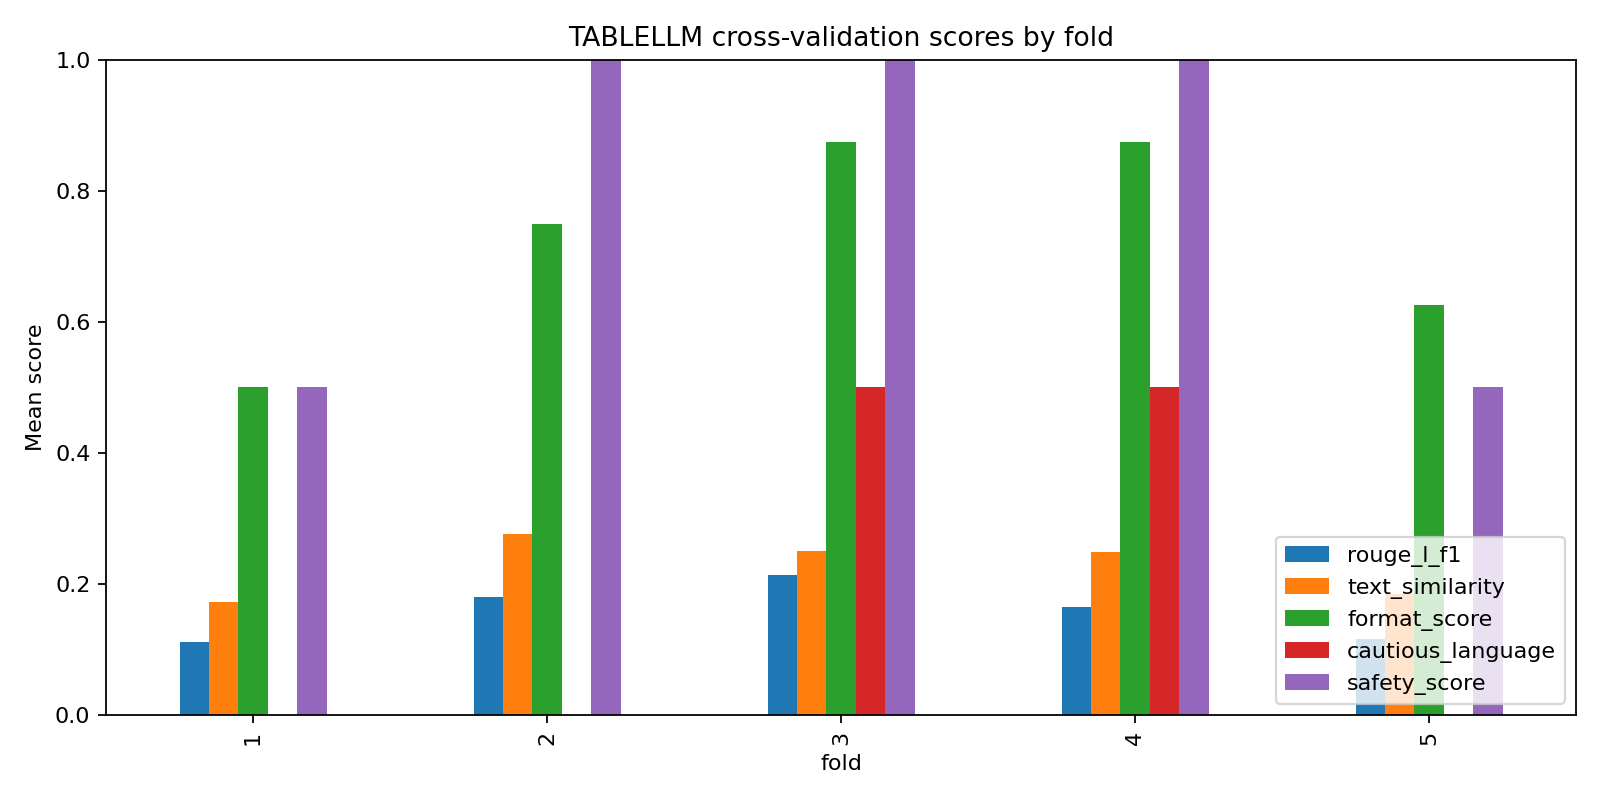

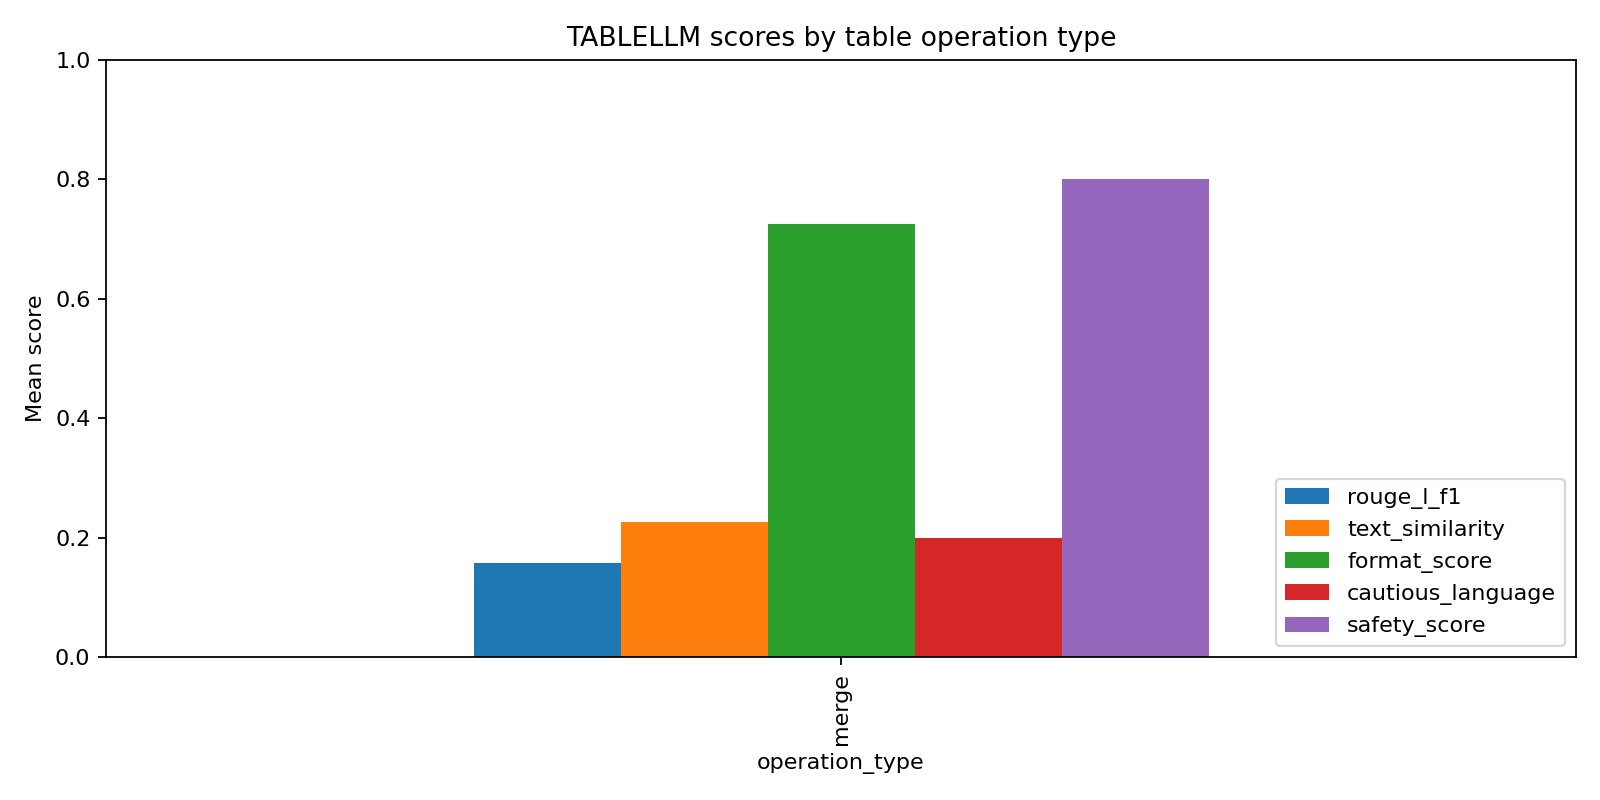

In [23]:
from IPython.display import Image, display

display(Image("/content/NLP_medical_results_explanation/outputs/tablellm_cv_real/tablellm_cv_fold_scores.png"))
display(Image("/content/NLP_medical_results_explanation/outputs/tablellm_cv_real/tablellm_cv_operation_scores.png"))